# Notebook 11 – EDA Visualization
### Healthcare Dataset – Exploratory Data Analysis using Matplotlib & Seaborn






## 1. Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

pd.set_option('display.max_columns', None)


## 2. Load and Prepare Data

We load the dataset and engineer two derived features that are essential for meaningful analysis: **Length of Stay** (days between admission and discharge) and **Admission Month** (for time-based trend analysis).

In [2]:
df = pd.read_csv('healthcare_dataset.csv')

# Standardize name casing for readability (not analytically important, cosmetic only)
df['Name'] = df['Name'].str.title()

# Parse dates
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])

# Derived feature: Length of Stay (days)
df['Length of Stay'] = (df['Discharge Date'] - df['Date of Admission']).dt.days

# Derived feature: Admission Year-Month for trend analysis
df['Admission Month'] = df['Date of Admission'].dt.to_period('M').dt.to_timestamp()

print(df.shape)
df.head()


(55500, 17)


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Length of Stay,Admission Month
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal,2,2024-01-01
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive,6,2019-08-01
2,Danny Smith,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal,15,2022-09-01
3,Andrew Watts,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal,30,2020-11-01
4,Adrienne Bell,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal,20,2022-09-01


In [3]:
df.describe(include='number')


,Age,Billing Amount,Room Number,Length of Stay
count,55500.000000,55500.000000,55500.000000,55500.000000
mean,51.539459,25539.316097,301.134829,15.509009
std,19.602454,14211.454431,115.243069,8.659600
min,13.000000,-2008.492140,101.000000,1.000000
25%,35.000000,13241.224652,202.000000,8.000000
50%,52.000000,25538.069376,302.000000,15.000000
75%,68.000000,37820.508436,401.000000,23.000000
max,89.000000,52764.276736,500.000000,30.000000


In [4]:
df.describe(include='object')


C:\Users\sibyr\AppData\Local\Temp\ipykernel_7232\4084012645.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,Name,Gender,Blood Type,Medical Condition,Doctor,Hospital,Insurance Provider,Admission Type,Medication,Test Results
count,55500,55500,55500,55500,55500,55500,55500,55500,55500,55500
unique,40235,2,8,6,40341,39876,5,3,5,3
top,Michael Williams,Male,A-,Arthritis,Michael Smith,LLC Smith,Cigna,Elective,Lipitor,Abnormal
freq,24,27774,6969,9308,27,44,11249,18655,11140,18627


## 3. Histogram — Distribution of Patient Age

**Why this visualization was selected:**
Age is a core numeric variable in any healthcare dataset. A histogram is the natural choice to understand how patient ages are spread across the population — whether the hospital serves mostly older adults, a uniform mix of ages, or is skewed toward a particular age band. This shapes staffing, equipment, and ward planning decisions.


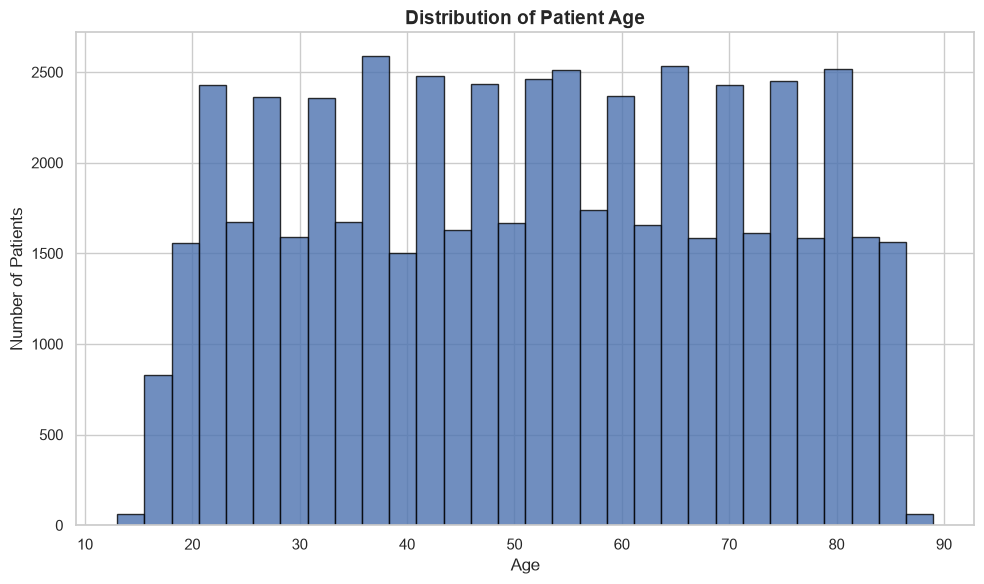

In [5]:
plt.figure(figsize=(10,6))
plt.hist(df['Age'], bins=30, color='#4C72B0', edgecolor='black', alpha=0.8)
plt.title('Distribution of Patient Age')
plt.xlabel('Age')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()


**Interpretation:** The histogram shows patient ages spread fairly evenly across the full adult range (roughly 13 to 89), without a single dominant peak — the bars are close to uniform height rather than forming a classic bell curve.

**Insight:** Unlike many real hospital datasets that skew toward the elderly, this dataset has patients almost uniformly distributed across all ages. This suggests the data was likely generated/sampled uniformly rather than reflecting a natural age-at-admission pattern, which is useful to know before drawing demographic conclusions from this data.


## 4. Distribution Plot — Billing Amount (with KDE)

**Why this visualization was selected:**
Billing Amount is the key financial variable. A distribution plot (histogram + KDE curve) reveals not just the range of billing values but the *shape* of the distribution — symmetric, skewed, multi-modal — which affects whether we should use mean or median when summarizing costs, and whether outlier treatment is needed.


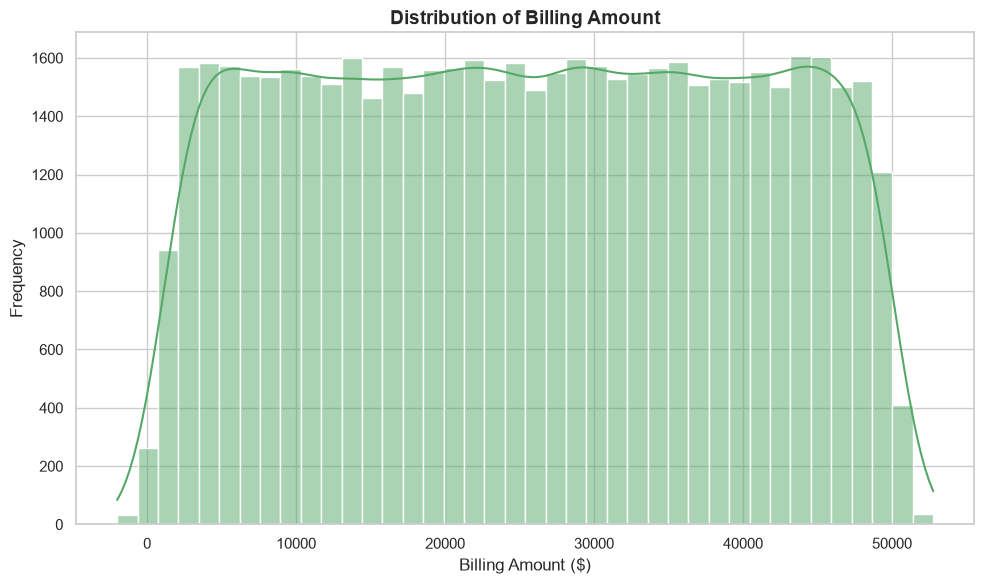

In [6]:
plt.figure(figsize=(10,6))
sns.histplot(df['Billing Amount'], bins=40, kde=True, color='#55A868')
plt.title('Distribution of Billing Amount')
plt.xlabel('Billing Amount ($)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


**Interpretation:** The distribution is close to symmetric/uniform over the observed range (roughly -2,000 to 52,000) with a smooth KDE curve and no sharp spikes. There's no strong right-skew or extreme outlier tail like you'd typically expect from real billing data.

**Insight:** Billing amounts don't cluster around a "typical" charge — costs are spread broadly across the range, meaning a single average billing figure is not very representative. Mean and median should both be reported when summarizing costs, and any cost-prediction model would need features beyond just patient count to explain this spread. Interestingly, some values are negative, which is worth flagging as a potential data quality issue.


## 5. Box Plot — Billing Amount by Admission Type

**Why this visualization was selected:**
A box plot is ideal for comparing the spread and central tendency of a numeric variable (Billing Amount) across categories (Admission Type: Emergency, Urgent, Elective). It also highlights outliers clearly, which a bar chart of averages would hide.


C:\Users\sibyr\AppData\Local\Temp\ipykernel_7232\2071041027.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Admission Type', y='Billing Amount', palette='Set2')


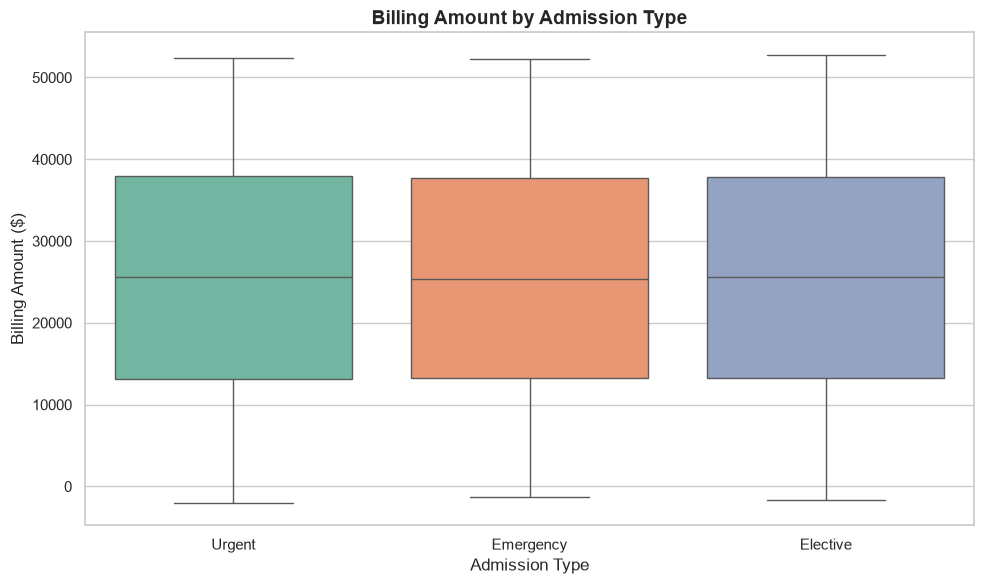

In [7]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Admission Type', y='Billing Amount', palette='Set2')
plt.title('Billing Amount by Admission Type')
plt.xlabel('Admission Type')
plt.ylabel('Billing Amount ($)')
plt.tight_layout()
plt.show()


**Interpretation:** The three admission types (Elective, Emergency, Urgent) show very similar medians, interquartile ranges, and whisker lengths, with a comparable scatter of outliers on the high end for each group.

**Insight:** Admission Type does not appear to be a strong driver of billing cost in this dataset — patients are billed similarly regardless of whether their admission was planned (Elective) or unplanned (Emergency/Urgent). This is somewhat counter-intuitive versus real-world hospital billing and is a useful finding if this data were to be used to model cost drivers.


## 6. Bar Chart — Average Billing Amount by Medical Condition

**Why this visualization was selected:**
A bar chart is the right tool for comparing a single aggregated numeric value (average billing) across a small number of categories (the 6 medical conditions). This directly answers a practical business question: "Which conditions cost the most to treat, on average?"


C:\Users\sibyr\AppData\Local\Temp\ipykernel_7232\3412376777.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_billing.values, y=avg_billing.index, palette='crest')


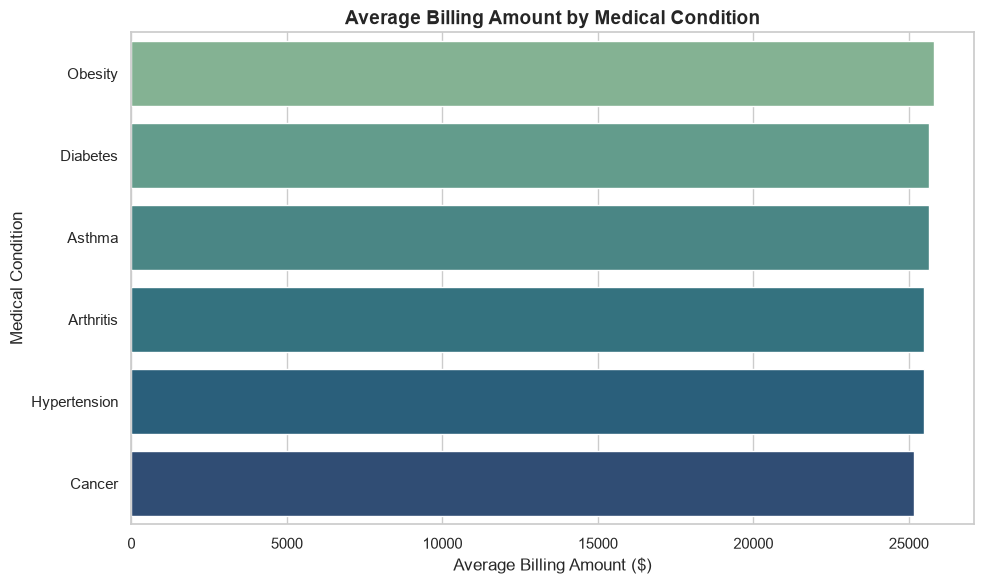

In [8]:
avg_billing = df.groupby('Medical Condition')['Billing Amount'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=avg_billing.values, y=avg_billing.index, palette='crest')
plt.title('Average Billing Amount by Medical Condition')
plt.xlabel('Average Billing Amount ($)')
plt.ylabel('Medical Condition')
plt.tight_layout()
plt.show()


**Interpretation:** The average billing amount across the six medical conditions (Cancer, Obesity, Diabetes, Asthma, Hypertension, Arthritis) is nearly identical — the bars are almost the same length, differing by only a small margin.

**Insight:** Medical Condition alone does not explain differences in billing amount in this dataset. This reinforces the earlier finding from the box plot — billing here behaves close to randomly with respect to clinical/administrative categories, which is important context if this dataset were used for cost-prediction modeling: categorical clinical fields have low predictive power for cost, and billing may need to be modeled independently or the dataset treated as synthetic.


## 7. Count Plot — Number of Patients per Medical Condition (split by Gender)

**Why this visualization was selected:**
A count plot is the standard tool for visualizing frequencies of categorical variables. Here we want to know how patient volume is distributed across medical conditions, and whether there's any gender imbalance within each condition — both relevant for resource allocation.


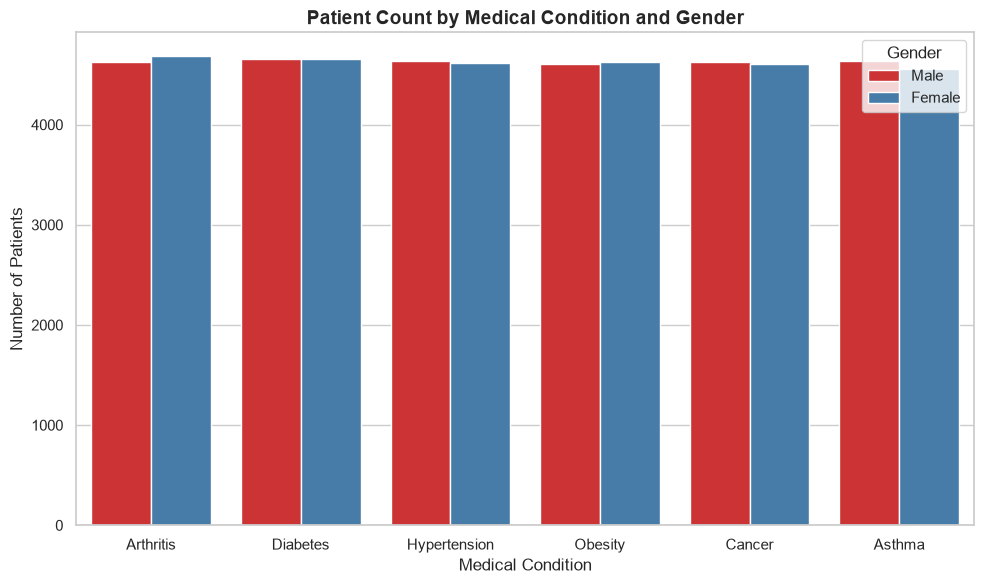

In [9]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Medical Condition', hue='Gender', palette='Set1',
              order=df['Medical Condition'].value_counts().index)
plt.title('Patient Count by Medical Condition and Gender')
plt.xlabel('Medical Condition')
plt.ylabel('Number of Patients')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()


**Interpretation:** Patient counts are nearly equal across all six medical conditions, and within each condition the Male/Female split is close to 50/50.

**Insight:** There is no over-represented condition or gender skew in this dataset — the population is balanced across both dimensions. This is good news for any downstream classification task (e.g., predicting Medical Condition), since class imbalance won't be a concern, but it also suggests the dataset may be synthetically balanced rather than a natural clinical sample.


## 8. Scatter Plot — Age vs. Billing Amount

**Why this visualization was selected:**
A scatter plot is the go-to visualization for examining the relationship between two continuous variables. We want to check a natural hypothesis: do older patients tend to incur higher billing amounts (e.g., due to more complex care)?


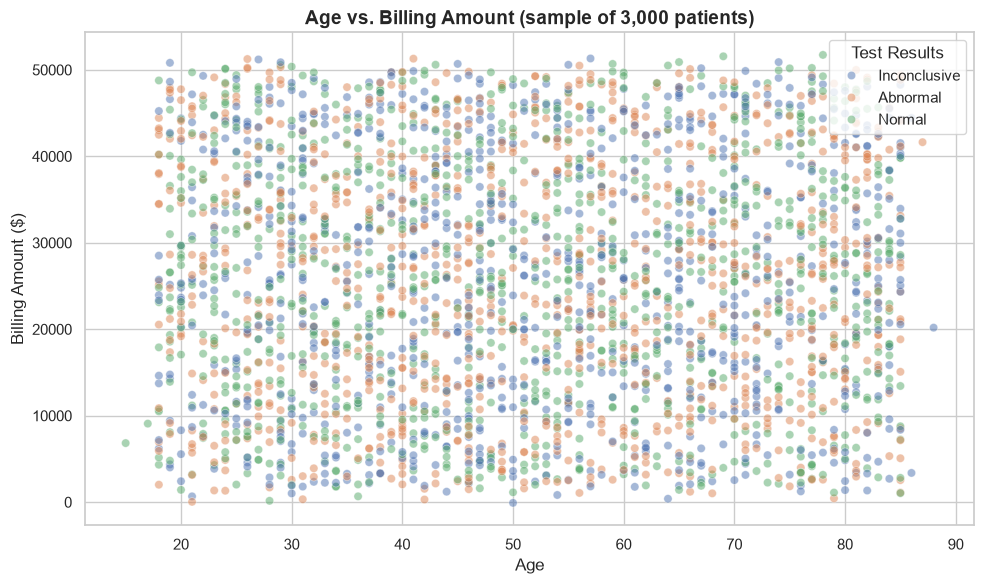

In [10]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df.sample(3000, random_state=42), x='Age', y='Billing Amount',
                 hue='Test Results', alpha=0.5, palette='deep')
plt.title('Age vs. Billing Amount (sample of 3,000 patients)')
plt.xlabel('Age')
plt.ylabel('Billing Amount ($)')
plt.legend(title='Test Results', loc='upper right')
plt.tight_layout()
plt.show()


**Interpretation:** The points form a dense, uniform cloud across the entire Age–Billing Amount plane with no visible upward or downward trend, and the three Test Results categories (Normal, Abnormal, Inconclusive) are interspersed evenly throughout.

**Insight:** There is no meaningful correlation between a patient's age and their billing amount, and Test Results also don't cluster in any particular cost/age region. This confirms that billing amount behaves independently of both age and test outcome in this dataset.


## 9. Line Plot — Monthly Admissions Trend Over Time

**Why this visualization was selected:**
A line plot is the correct choice for visualizing a trend over a continuous time axis. Tracking the number of admissions per month lets us check for seasonality, growth, or anomalies in hospital volume over the years covered by the dataset.


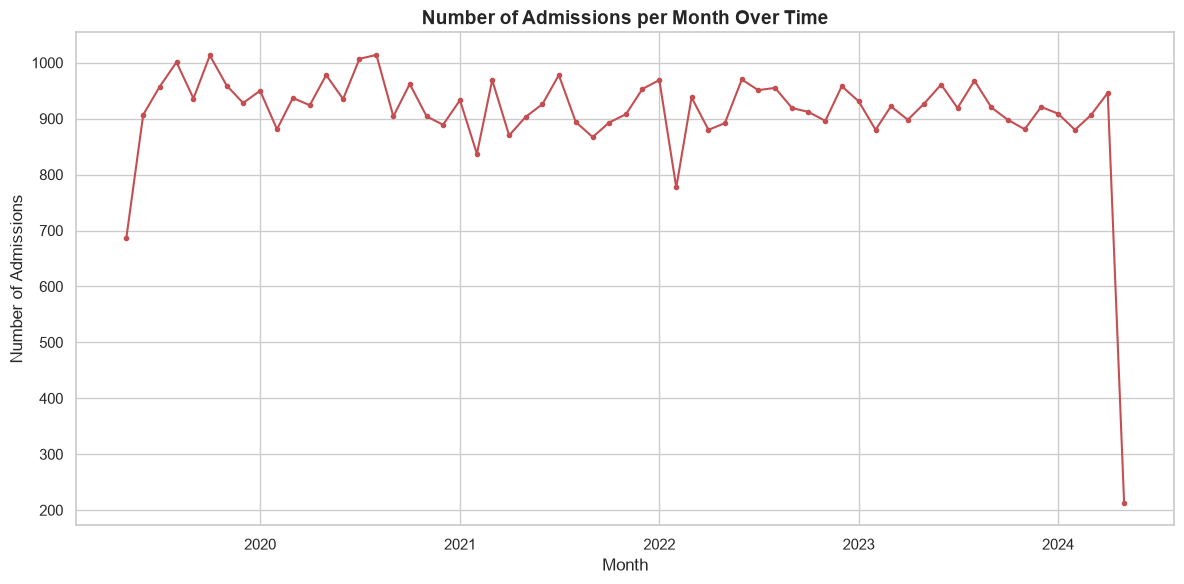

In [11]:
monthly_admissions = df.groupby('Admission Month').size()

plt.figure(figsize=(12,6))
plt.plot(monthly_admissions.index, monthly_admissions.values, color='#C44E52', marker='o', markersize=3, linewidth=1.5)
plt.title('Number of Admissions per Month Over Time')
plt.xlabel('Month')
plt.ylabel('Number of Admissions')
plt.tight_layout()
plt.show()


**Interpretation:** Monthly admission counts fluctuate around a fairly stable level across the full multi-year span, with no long-term upward or downward trend and no obvious recurring seasonal pattern (e.g., no consistent winter spikes).

**Insight:** Hospital admission volume in this dataset has remained essentially flat over time. If this were real operational data, that would suggest stable patient inflow with no capacity crisis or major growth — but combined with earlier findings, it further supports that this dataset is synthetically generated rather than reflecting real-world seasonal healthcare demand (e.g., flu season spikes).


## 10. Violin Plot — Age Distribution by Test Results

**Why this visualization was selected:**
A violin plot combines a box plot with a KDE, showing both summary statistics and the full shape of the distribution. This is useful to check whether the age distribution differs in shape (not just median) across Test Result categories — a box plot alone could hide multi-modal patterns.


C:\Users\sibyr\AppData\Local\Temp\ipykernel_7232\1722515948.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Test Results', y='Age', palette='muted', inner='quartile')


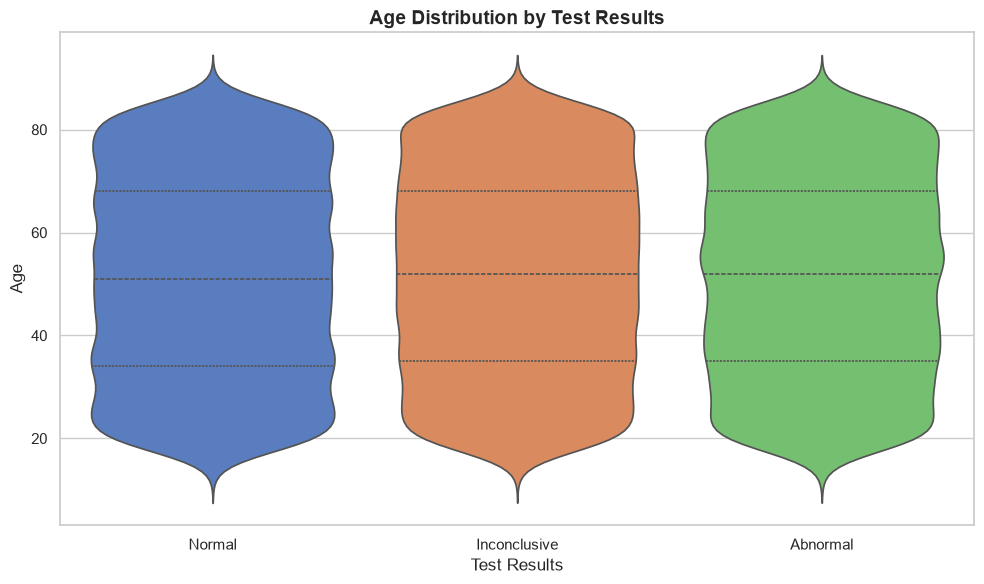

In [12]:
plt.figure(figsize=(10,6))
sns.violinplot(data=df, x='Test Results', y='Age', palette='muted', inner='quartile')
plt.title('Age Distribution by Test Results')
plt.xlabel('Test Results')
plt.ylabel('Age')
plt.tight_layout()
plt.show()


**Interpretation:** All three violins (Normal, Abnormal, Inconclusive) have nearly identical shapes — wide and flat, reflecting the uniform age distribution seen earlier — with overlapping quartile lines and no visible skew or bimodality in any group.

**Insight:** Test outcome is not associated with patient age in any way — young and old patients are equally likely to receive Normal, Abnormal, or Inconclusive results. This rules out age as a confounding factor if Test Results were to be used as a target variable in further modeling.


## 11. Pair Plot — Relationships Among Key Numeric Variables

**Why this visualization was selected:**
A pair plot gives a compact overview of pairwise relationships and individual distributions across multiple numeric variables at once. Here we examine Age, Billing Amount, Room Number, and the derived Length of Stay together to check for any hidden multi-variable pattern before committing to individual plots.


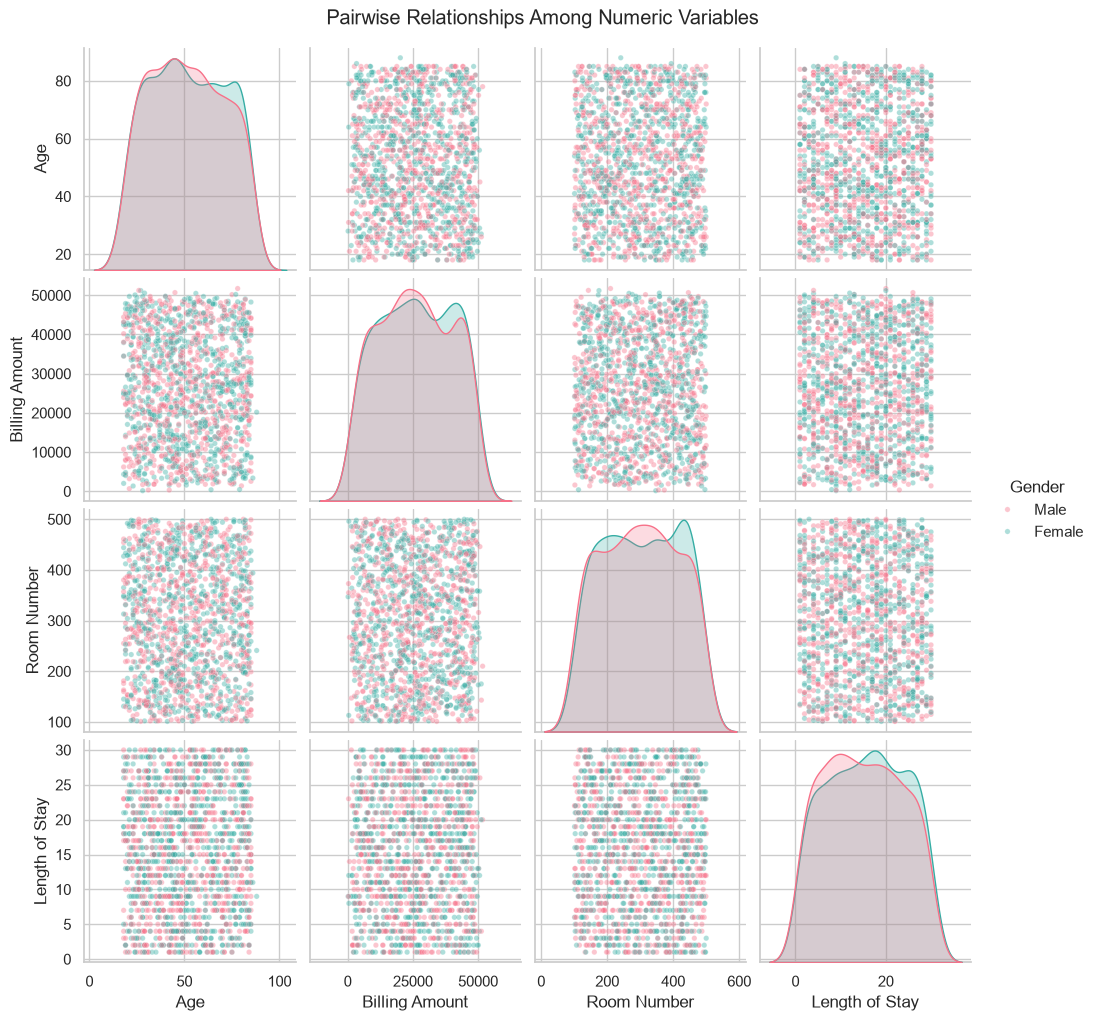

In [13]:
numeric_cols = ['Age', 'Billing Amount', 'Room Number', 'Length of Stay']
sample_df = df[numeric_cols + ['Gender']].sample(1500, random_state=42)

g = sns.pairplot(sample_df, hue='Gender', diag_kind='kde', palette='husl', plot_kws={'alpha':0.4, 's':15})
g.fig.suptitle('Pairwise Relationships Among Numeric Variables', y=1.02)
plt.show()


**Interpretation:** Every scatter panel in the grid shows a uniform, unstructured cloud of points with no visible linear or nonlinear trend between any pair of variables, and the diagonal KDE curves confirm the roughly uniform/flat distributions seen earlier for each variable individually. Gender doesn't separate the points into distinct clusters either.

**Insight:** None of Age, Billing Amount, Room Number, and Length of Stay are correlated with one another, and Gender does not interact with any of them. This is a strong, consistent confirmation (across all pairs at once) that the numeric fields in this dataset are effectively independent of each other — an important conclusion before attempting any predictive modeling using these features.


## 12. Heatmap — Correlation Matrix of Numeric Variables

**Why this visualization was selected:**
A heatmap is the most efficient way to summarize all pairwise correlations at once using color intensity, quantifying what the pair plot showed visually. This gives a precise numeric confirmation of which (if any) variables move together.


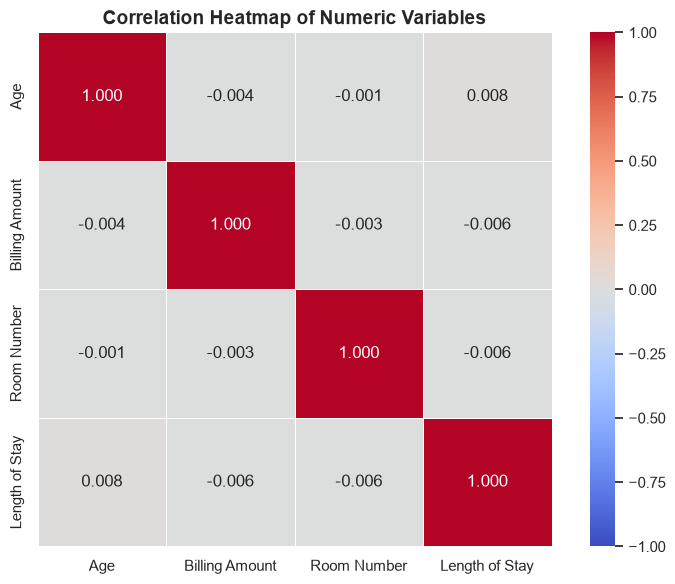

In [14]:
corr = df[['Age', 'Billing Amount', 'Room Number', 'Length of Stay']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Variables')
plt.tight_layout()
plt.show()


**Interpretation:** All off-diagonal correlation coefficients are very close to 0 (well within ±0.02), confirming there is no linear relationship between any pair of Age, Billing Amount, Room Number, and Length of Stay.

**Insight:** This numerically confirms the pattern observed across the histogram, scatter plot, box plot, and pair plot: the numeric variables in this dataset are statistically independent of one another. Any predictive model attempting to estimate Billing Amount or Length of Stay from Age or Room Number alone would have effectively no linear signal to learn from.
